# Patient 001 — Pipeline Results Interpretation

**Patient:** SRR9143066 (gastric cancer, primary tumor)  
**Normal:** SRR9143065 (Solid Tissue Normal, adjacent stomach tissue)  
**Run:** valid run after Issue #148 (HISAT2 chr-naming fix), part of production run #123  
**Date:** 2026-04-29  
**Analyst:** Scientist

---

> **Note:** patient_001 has a matched RNA-seq normal (adjacent stomach tissue). Junction filtering applied this normal to subtract tissue-specific and germline splicing events — the `tumor_exclusive` label is more stringent here than for patient_002 (which had only WES normal, contributing zero RNA junctions).

In [1]:
import subprocess
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BUCKET = "gs://splice-neoepitope-project/results/patient_001"
CACHE_DIR = "/tmp/splice-neoepitope-cache/patient_001"

def gcs_read_tsv_cached(path):
    filename = os.path.basename(path)
    local_path = os.path.join(CACHE_DIR, filename)
    os.makedirs(CACHE_DIR, exist_ok=True)
    if not os.path.exists(local_path):
        # parallel_process_count=1 avoids the macOS gsutil fork bug
        # (https://bugs.python.org/issue33725) — multithreading still active.
        # Write to .tmp then rename atomically so a partial download can't
        # poison the cache.
        tmp_path = local_path + ".tmp"
        try:
            subprocess.run(
                ["gsutil", "-o", "GSUtil:parallel_process_count=1", "cp", path, tmp_path],
                check=True,
            )
            os.rename(tmp_path, local_path)
        except Exception:
            if os.path.exists(tmp_path):
                os.remove(tmp_path)
            raise
    return pd.read_csv(local_path, sep="\t")

print("Setup complete.")

Setup complete.


## 1. Run Summary

In [2]:
report = gcs_read_tsv_cached(f"{BUCKET}/reports/report.tsv")
report

Copying gs://splice-neoepitope-project/results/patient_001/reports/report.tsv...


/ [1 files][  1.1 KiB/  1.1 KiB]                                                
Operation completed over 1 objects/1.1 KiB.                                      


,patient_id,stage,metric,value,notes
0,patient_001,junction_filtering,unannotated,30029,SRR9143066 (Primary Tumor)
1,patient_001,junction_filtering,tumor_exclusive,27348,SRR9143066 (Primary Tumor)
2,patient_001,junction_filtering,normal_shared,2681,SRR9143066 (Primary Tumor)
3,patient_001,mhc_prediction,total_predictions,1286492,NaN
4,patient_001,mhc_prediction,non,1115801,presentation_percentile > 2.0%
5,patient_001,mhc_prediction,weak,125775,presentation_percentile <= 2.0%
6,patient_001,mhc_prediction,strong,44916,presentation_percentile <= 0.5%
7,patient_001,top_candidate,peptide,SQIPRTHSY,top by genotype_presentation_score
8,patient_001,top_candidate,allele,HLA-C*07:01,NaN
9,patient_001,top_candidate,presentation_percentile,0.0052,NaN


## 2. Junction Analysis

### 2.1 Read-support distribution

A healthy RNA-seq junction call should show a right-skewed distribution: most junctions supported by a modest number of reads, a long tail of highly-expressed junctions. Junctions with very low read support (< ~5 reads) are typically noise and would normally be filtered; junctions with very high support are likely recurrent splicing events.

With a matched RNA-seq normal applied, the tumor-exclusive set here has been filtered against tissue-specific and germline splicing events present in adjacent normal stomach tissue. The pipeline also applies a dynamic per-file mean filter (keeps only junctions strictly above the per-sample mean read count, per Developer answer 2026-04-26).

Copying gs://splice-neoepitope-project/results/patient_001/junctions/novel_junctions.tsv...


- [1 files][  2.8 MiB/  2.8 MiB]                                                
Operation completed over 1 objects/2.8 MiB.                                      


Unannotated junctions:         30,029
  ├─ normal_shared (removed):   2,681
  └─ tumor_exclusive:         27,348   ← carried forward to MHC prediction

Read support stats (tumor_exclusive):
count    27348.000000
mean        48.602567
std        540.127786
min         16.000000
25%         20.000000
50%         26.000000
75%         42.000000
max      82098.000000


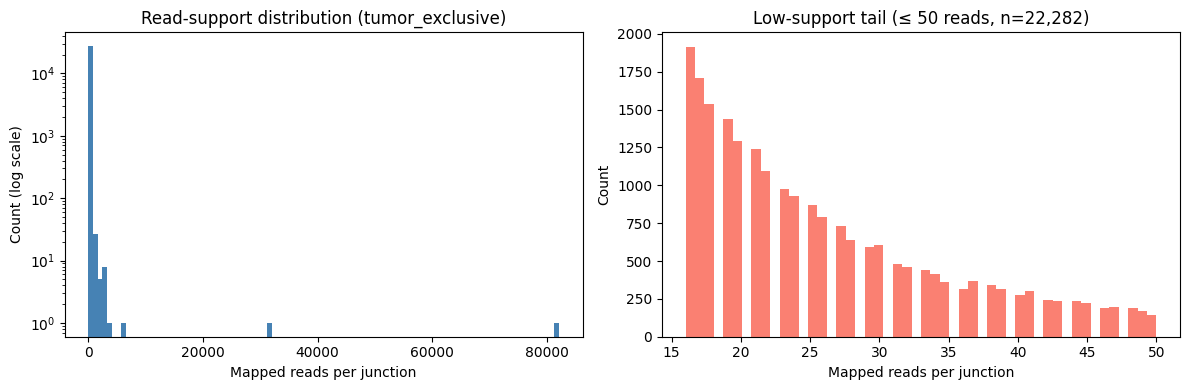

In [3]:
junctions = gcs_read_tsv_cached(f"{BUCKET}/junctions/novel_junctions.tsv")

n_unannotated = len(junctions)
n_normal_shared = (junctions["junction_origin"] == "normal_shared").sum()
junctions = junctions[junctions["junction_origin"] == "tumor_exclusive"].reset_index(drop=True)
n_tumor_exclusive = len(junctions)

print(f"Unannotated junctions:        {n_unannotated:>7,}")
print(f"  ├─ normal_shared (removed): {n_normal_shared:>7,}")
print(f"  └─ tumor_exclusive:        {n_tumor_exclusive:>7,}   ← carried forward to MHC prediction")
print(f"\nRead support stats (tumor_exclusive):")
print(junctions["mapped_reads"].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution (log scale)
axes[0].hist(junctions["mapped_reads"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_yscale("log")
axes[0].set_xlabel("Mapped reads per junction")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("Read-support distribution (tumor_exclusive)")

# Zoomed: low-support tail (≤ 50 reads)
low = junctions[junctions["mapped_reads"] <= 50]
axes[1].hist(low["mapped_reads"], bins=50, color="salmon", edgecolor="none")
axes[1].set_xlabel("Mapped reads per junction")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Low-support tail (≤ 50 reads, n={len(low):,})")

plt.tight_layout()
plt.show()

## 3. Peptide Translation

How many junction-spanning peptides were translated, across which lengths? The pipeline extracts all peptides spanning the junction breakpoint across all three reading frames.

Copying gs://splice-neoepitope-project/results/patient_001/peptides/peptides_novel.tsv...


| [1 files][ 97.5 MiB/ 97.5 MiB]    4.7 MiB/s                                   
Operation completed over 1 objects/97.5 MiB.                                     


Total peptides: 1,286,492
Unique sequences: 1,260,074

Peptide length distribution:
peptide
8     382792
9     430178
10    473522


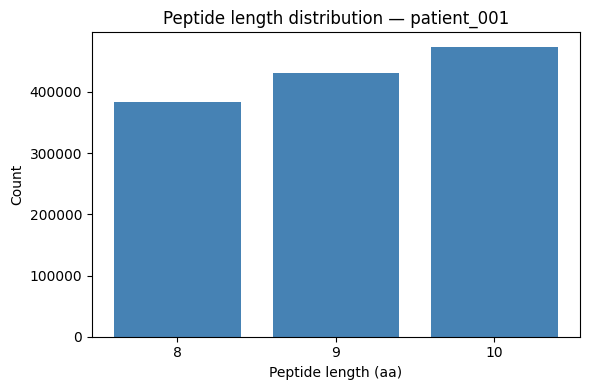

In [4]:
peptides = gcs_read_tsv_cached(f"{BUCKET}/peptides/peptides_novel.tsv")
print(f"Total peptides: {len(peptides):,}")
print(f"Unique sequences: {peptides['peptide'].nunique():,}")

length_counts = peptides["peptide"].str.len().value_counts().sort_index()
print(f"\nPeptide length distribution:")
print(length_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(length_counts.index, length_counts.values, color="steelblue")
ax.set_xlabel("Peptide length (aa)")
ax.set_ylabel("Count")
ax.set_title("Peptide length distribution — patient_001")
ax.set_xticks(length_counts.index)
plt.tight_layout()
plt.show()

## 4. MHC Prediction Summary

### 4.1 Presentation class breakdown

How do peptide–allele predictions distribute across the strong (≤ 0.5th percentile), weak (≤ 2nd percentile), and non-presenter classes?

Copying gs://splice-neoepitope-project/results/patient_001/predictions/mhc_presentation.tsv...


- [1 files][535.8 MiB/535.8 MiB]    1.3 MiB/s                                   
Operation completed over 1 objects/535.8 MiB.                                    


Total predictions loaded: 1,286,492

Presentation class breakdown:
presentation_class
strong      44916
weak       125775
non       1115801


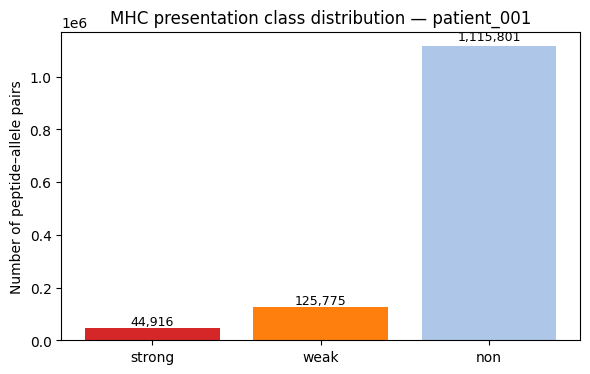

In [5]:
pres = gcs_read_tsv_cached(f"{BUCKET}/predictions/mhc_presentation.tsv")
print(f"Total predictions loaded: {len(pres):,}")

class_counts = pres["presentation_class"].value_counts().reindex(["strong", "weak", "non"], fill_value=0)
print("\nPresentation class breakdown:")
print(class_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_counts.index, class_counts.values, color=["#d62728", "#ff7f0e", "#aec7e8"])
ax.set_ylabel("Number of peptide–allele pairs")
ax.set_title("MHC presentation class distribution — patient_001")
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 HLA allele dominance

Which alleles are the strongest presenters? patient_001's MHCflurry predictions ran against the tumor HLA calls: HLA-A\*31:01/A\*26:01, HLA-B\*15:63/B\*18:01, HLA-C\*07:01/C\*03:03 (per the tumor-first policy now in use). The HLA-C dominance pattern observed in patient_002 (HLA-C\*01:02 / C\*07:01 = ~69% of strong presenters) — does it persist with this patient's different HLA-C alleles, or is it patient/cancer-type specific?

Strong presenters per allele:
best_allele
HLA-C*03:03    15123
HLA-A*31:01    12685
HLA-C*07:01    10547
HLA-B*18:01     4068
HLA-A*26:01     1344
HLA-B*15:63     1149


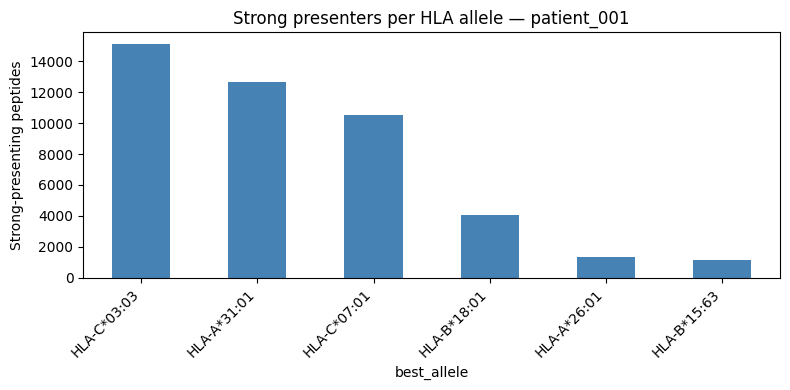

In [6]:
strong = pres[pres["presentation_class"] == "strong"]
allele_counts = strong["best_allele"].value_counts()
print("Strong presenters per allele:")
print(allele_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
allele_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Strong-presenting peptides")
ax.set_title("Strong presenters per HLA allele — patient_001")
ax.set_xticklabels(allele_counts.index, rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Top Candidates

### 5.1 Top 20 by genotype presentation score

`genotype_presentation_score` (GPS) ranks candidates across the full patient HLA genotype — it rewards peptides presented by multiple alleles. This is the primary ranking used for prioritisation.

In [7]:
top20 = (pres.sort_values("genotype_presentation_score", ascending=False)
           .head(20)
           [["peptide", "best_allele", "ic50_nM", "presentation_percentile",
             "genotype_presentation_score", "n_strong_alleles", "presentation_class"]])
top20.reset_index(drop=True, inplace=True)
top20.index += 1
top20

,peptide,best_allele,ic50_nM,presentation_percentile,genotype_presentation_score,n_strong_alleles,presentation_class
1,SQIPRTHSY,HLA-C*07:01,33.605508,0.005245,0.999937,5,strong
2,DAYDRPVSY,HLA-A*26:01,32.512572,0.002065,0.999933,4,strong
3,SQLPTTVAY,HLA-C*07:01,54.425385,0.012092,0.999896,4,strong
4,VAPPPSHAL,HLA-C*03:03,19.099147,0.001114,0.999873,5,strong
5,QAYDNPLSY,HLA-C*07:01,50.586613,0.017663,0.999837,5,strong
6,HQAEPGSAAY,HLA-B*18:01,81.889620,0.044076,0.999831,5,strong
7,ESIDHQLTY,HLA-A*26:01,26.991266,0.002065,0.999827,4,strong
8,MLIDPSGVSY,HLA-C*03:03,57.481116,0.010870,0.999822,5,strong
9,SLFERTTTY,HLA-C*07:01,80.619318,0.024049,0.999814,4,strong
10,HVYPGGAGAF,HLA-A*26:01,30.825106,0.010870,0.999800,4,strong


### 5.2 Top candidate: SQIPRTHSY / HLA-C\*07:01

**IC50 = 33.6 nM | presentation_percentile = 0.0052% | GPS = 0.9999 | n_strong_alleles = 5**

Key observations:
- IC50 of ~34 nM places this well into strong-presenter territory (threshold: 500 nM; typical strong presenter < 50 nM).
- The 0.0052th percentile is exceptionally low — this peptide ranks in the top 0.005% of all HLA-C\*07:01-presented peptides, suggesting high intrinsic affinity rather than a borderline call.
- Presented as strong by **5 of 6 patient alleles** (GPS ≈ 1.0), making it the most genotype-broadly presented candidate. Comparable breadth to patient_002's FADLRPLLL (4/5 alleles, ~80%); patient_001's SQIPRTHSY achieves 5/6 (~83%).
- **Cross-patient note:** HLA-C\*07:01 is shared between patient_001 and patient_002 (per `patient_002_results.ipynb` §1 `report.tsv`: HLA-C = C\*01:02 / C\*07:01 for patient_002, vs C\*07:01 / C\*03:03 for patient_001 above). patient_002's top candidate sat on HLA-C\*01:02; patient_001's tops on HLA-C\*07:01. Notable that both top candidates land at GPS ≈ 0.9999, IC50 ≈ 33–34 nM despite different splice contexts and different HLA-C alleles — suggests a structural ceiling around the GPS-best slot rather than a peptide-specific outlier.

**Strength relative to patient_002:** patient_001 has a matched RNA-seq normal applied, so the originating junction has already been filtered against tissue-specific splicing in adjacent stomach tissue — a stronger tumor-exclusivity claim than patient_002's WES-only normal.

## 6. Genotype Presentation Score (GPS) — Validation

GPS = $1 - \prod_i (1 - w_i \cdot p_i)$ where $p_i$ is per-allele `presentation_score` and $w_i$ is locus weight (HLA-A/B = 1.0, HLA-C = 0.5; the weighting is approximate — MHCflurry applies its own locus-aware calibration internally during scoring). It estimates the probability that **at least one allele** in the patient's genotype presents the peptide. Primary ranking signal for the vaccine context; backed by a quality gate (`best_presentation_percentile ≤ 2%`).

Questions to answer empirically:
1. How is GPS distributed across all predictions — is it discriminating or does everyone score high?
2. Does GPS correlate with `n_strong_alleles` as expected?
3. Are there candidates with high GPS but poor best-allele percentile (the "inflation" edge case)?
4. Per-allele contribution: which alleles drive GPS most in this patient?

### 6.1 GPS distribution

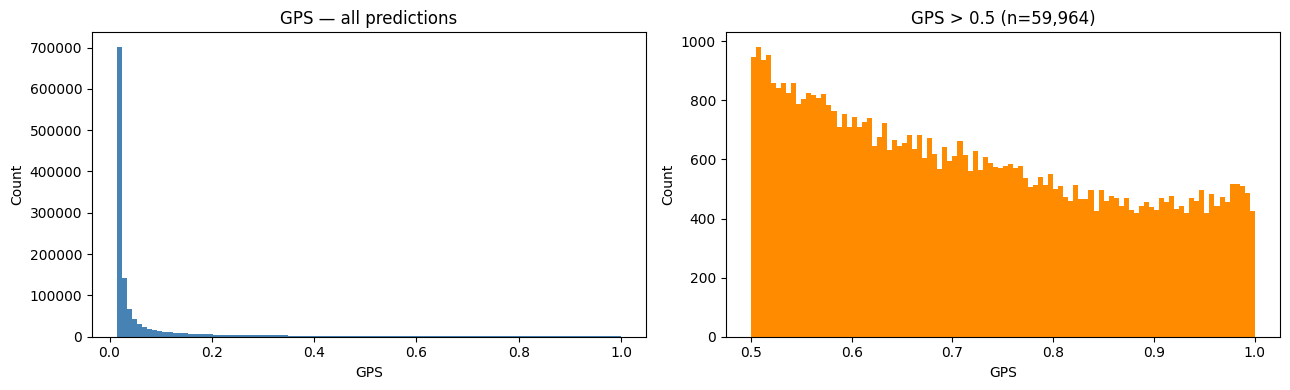


GPS summary stats:
count    1.286492e+06
mean     8.895305e-02
std      1.661496e-01
min      1.475000e-02
25%      1.752000e-02
50%      2.252900e-02
75%      5.797400e-02
max      9.999370e-01

GPS > 0.9: 9,276
GPS > 0.99: 914


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full distribution
axes[0].hist(pres["genotype_presentation_score"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("GPS")
axes[0].set_ylabel("Count")
axes[0].set_title("GPS — all predictions")

# Zoom into the high end (> 0.5) where interesting candidates live
high = pres[pres["genotype_presentation_score"] > 0.5]
axes[1].hist(high["genotype_presentation_score"], bins=100, color="darkorange", edgecolor="none")
axes[1].set_xlabel("GPS")
axes[1].set_ylabel("Count")
axes[1].set_title(f"GPS > 0.5 (n={len(high):,})")

plt.tight_layout()
plt.show()

print(f"\nGPS summary stats:")
print(pres["genotype_presentation_score"].describe().to_string())
print(f"\nGPS > 0.9: {(pres['genotype_presentation_score'] > 0.9).sum():,}")
print(f"GPS > 0.99: {(pres['genotype_presentation_score'] > 0.99).sum():,}")

### 6.2 GPS vs n_strong_alleles — does breadth drive the score?

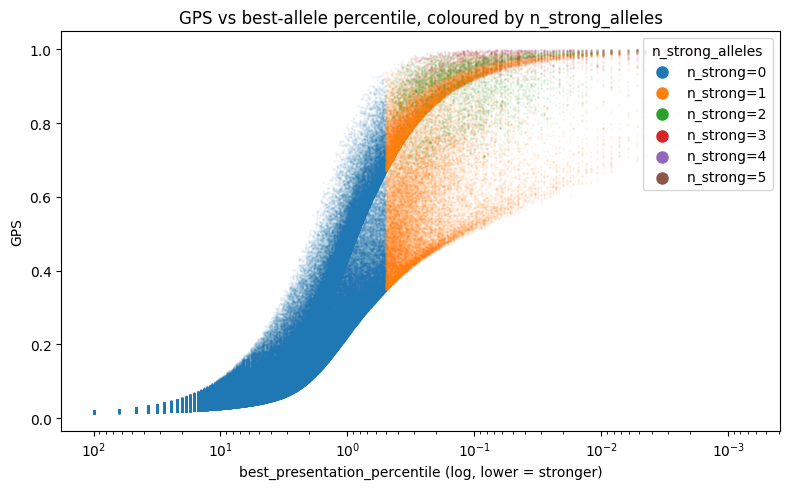

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for n, grp in pres.groupby("n_strong_alleles"):
    ax.scatter(grp["best_presentation_percentile"], grp["genotype_presentation_score"],
               alpha=0.05, s=1, label=f"n_strong={n}")

ax.set_xscale("log")
ax.set_xlabel("best_presentation_percentile (log, lower = stronger)")
ax.set_ylabel("GPS")
ax.set_title("GPS vs best-allele percentile, coloured by n_strong_alleles")
ax.invert_xaxis()
legend = ax.legend(markerscale=8, title="n_strong_alleles", loc="upper right")
for lh in legend.legend_handles:
    lh.set_alpha(1)
plt.tight_layout()
plt.show()

### 6.3 Inflation check — high GPS with no strong allele

In [10]:
# Candidates with GPS > 0.9 but n_strong_alleles == 0.
# These are NOT caught by the current quality gate (best_presentation_percentile <= 2%) —
# their best_percentile is just above the strong threshold (0.5%), so GPS inflates from
# allele breadth rather than per-allele strength.
# patient_002 had 174 such cases; comparing here.
inflated = pres[(pres["genotype_presentation_score"] > 0.9) & (pres["n_strong_alleles"] == 0)]
print(f"GPS > 0.9 with n_strong_alleles = 0: {len(inflated):,}")
if len(inflated) > 0:
    print("\nTop 10 by GPS:")
    print(inflated.nlargest(10, "genotype_presentation_score")
          [["peptide", "best_allele", "best_presentation_percentile",
            "genotype_presentation_score", "n_strong_alleles"]].to_string())

GPS > 0.9 with n_strong_alleles = 0: 25

Top 10 by GPS:
            peptide  best_allele  best_presentation_percentile  genotype_presentation_score  n_strong_alleles
1003715   HQKELVQCW  HLA-B*18:01                      0.523071                     0.934993                 0
379486    HLFPPSWLY  HLA-C*07:01                      0.534701                     0.930014                 0
54121    DQFPGFPKKF  HLA-B*18:01                      0.567065                     0.928952                 0
15000     AIKSVEVHY  HLA-B*15:63                      0.551168                     0.925719                 0
626429    LPVPVFLKY  HLA-C*03:03                      0.633342                     0.925511                 0
739123    AVFFSGDSY  HLA-A*26:01                      0.584973                     0.924423                 0
293209    DVVLNGSFR  HLA-A*26:01                      0.518125                     0.923338                 0
716744    KVTNTITSY  HLA-A*26:01                      0.518125  

### 6.4 Per-allele contribution to GPS

     allele  median_pres_score_strong  pct_as_best_allele  median_percentile_strong
HLA-A*26:01                  0.025162            2.992252                  9.494239
HLA-A*31:01                  0.051534           28.241607                  4.968641
HLA-B*15:63                  0.049125            2.558108                  5.149212
HLA-B*18:01                  0.022143            9.056906                 10.655842
HLA-C*03:03                  0.333129           33.669516                  1.252935
HLA-C*07:01                  0.214718           23.481610                  1.749049


/var/folders/ny/97nfvbms25lb47qpfvgmgfc40000gn/T/ipykernel_21910/3370794731.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(summary["allele"], rotation=30, ha="right")
/var/folders/ny/97nfvbms25lb47qpfvgmgfc40000gn/T/ipykernel_21910/3370794731.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(summary["allele"], rotation=30, ha="right")


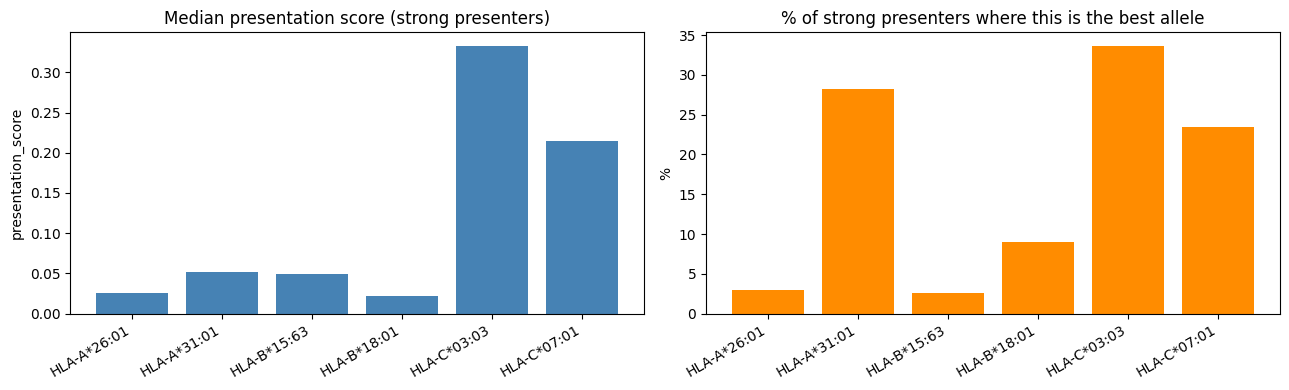

In [11]:
# Derive alleles from column names — works across patients without modification
alleles = sorted([c.replace("_presentation_score", "")
                  for c in pres.columns if c.endswith("_presentation_score")
                  and c.startswith("HLA-")])
score_cols = [f"{a}_presentation_score" for a in alleles]
pct_cols   = [f"{a}_presentation_percentile" for a in alleles]

strong = pres[pres["presentation_class"] == "strong"]

summary = pd.DataFrame({
    "allele": alleles,
    "median_pres_score_strong": [strong[c].median() for c in score_cols],
    "pct_as_best_allele": [
        (strong["best_allele"] == a).sum() / len(strong) * 100 for a in alleles
    ],
    "median_percentile_strong": [strong[c].median() for c in pct_cols],
})
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(summary["allele"], summary["median_pres_score_strong"], color="steelblue")
axes[0].set_title("Median presentation score (strong presenters)")
axes[0].set_ylabel("presentation_score")
axes[0].set_xticklabels(summary["allele"], rotation=30, ha="right")

axes[1].bar(summary["allele"], summary["pct_as_best_allele"], color="darkorange")
axes[1].set_title("% of strong presenters where this is the best allele")
axes[1].set_ylabel("%")
axes[1].set_xticklabels(summary["allele"], rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 7. Scientific Summary & Open Questions

### Key findings

1. **Top candidate SQIPRTHSY / HLA-C\*07:01** — IC50 33.6 nM, percentile 0.0052%, GPS 0.9999, strong presenter across 5/6 alleles (vs patient_002's FADLRPLLL: 4/5 ≈ 80%; SQIPRTHSY: 5/6 ≈ 83%). Both patients' top candidates land at GPS ≈ 0.9999 / IC50 ≈ 33–34 nM despite different HLA-C alleles — looks like a ceiling effect at the GPS-best slot rather than a peptide-specific outlier.
2. **HLA-C dominance partially recapitulated** — HLA-C\*03:03 (33.7%) + HLA-C\*07:01 (23.5%) = ~57% of strong presenters (vs ~69% in patient_002). Less extreme but still HLA-C-dominated despite different alleles, suggesting the dominance is more general than allele-specific. Consistent with the hypothesis that HLA-C alleles are intrinsically more promiscuous and/or that MHCflurry's percentile calibration is uniformly looser for HLA-C.
3. **HLA-A\*31:01 surprisingly active** — 28.2% as best allele, median percentile 5.0 among strong presenters. Markedly different from patient_002's HLA-A\*01:01 which was nearly silent (median percentile 8.5%). Patient_001's HLA-A is a real contributor to GPS, not just filler.
4. **HLA-B\*18:01 is the quietest in patient_001** — median percentile 10.7 among strong presenters. Analogous role to HLA-A\*01:01 in patient_002 — every patient has a "passenger" allele.
5. **GPS is discriminating** — mean 0.089, median 0.023; only 0.72% of predictions exceed GPS 0.9 (vs 1.1% in patient_002). Slightly tighter distribution. The complementary-probability formula behaves well across patients.
6. **GPS inflation edge case smaller in patient_001** — only 25 candidates with GPS > 0.9 and n_strong_alleles = 0 (vs 174 in patient_002 — 7× drop). May reflect fewer "borderline-allele breadth" cases when individual allele strengths are more clearly separated.
7. **Junction count 27,348** — after matched-normal filtering removed 2,681 of 30,029 unannotated junctions (8.9%). Roughly half of patient_002's 58,914 (which had no matched-normal applied). The clean tumor-exclusive count is what feeds MHC prediction downstream.
8. **Read support ~11× lower than patient_002** — tumor_exclusive read-support, patient_001 vs patient_002: min 16 vs 174, median 26 vs 425, mean 49 vs 953, max 82,098 vs 295,679. Per-file mean filter parameter (the threshold used to filter low-support junctions) is ~15 for patient_001 vs ~173 for patient_002. Patient_001 sample has substantially shallower sequencing depth and/or lower expression of these junctions.

### Open questions / next steps

- **Cross-patient comparison notebook** — assemble side-by-side metrics for patient_001 vs patient_002 (eventually all patients) once the run registry (Issue #186 follow-up) is in place.
- **HLA-C calibration** — the persistence of HLA-C dominance across patients with different HLA-C alleles strengthens the calibration hypothesis. Cross-validate top HLA-C candidates with NetMHCpan-4.1 to test whether MHCflurry's HLA-C signal is over-called.
- **GPS quality gate** — `n_strong_alleles ≥ 1` filter and/or GPS_gated alternative — pending design discussion. The smaller patient_001 inflation count (25) makes the gate impact more tractable to assess.
- **HLA-typing policy doc** — RESULTS.md still describes HLA typing under the legacy "normal-first policy" wording; the actual MHCflurry alleles here are the tumor-first calls (B\*15:63 / B\*18:01). Worth a separate doc-correction PR to reconcile.